# Import Statements

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
from skimage import exposure
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2

# Reading the Dataset

In [ ]:
!ls

'archive (2).zip'   sample_data


In [ ]:
!rm -r /content/COVID-19_Radiography_Dataset

rm: cannot remove '/content/COVID-19_Radiography_Dataset': No such file or directory


In [ ]:
!unzip -oq /content/Dataset.zip -d /content/

The file is unzipped and the data is loaded in the notebook.

In [6]:
dataset_path = './COVID-19_Radiography_Dataset/'
categories = ['COVID', 'Lung_Opacity', 'Normal','Viral Pneumonia']

## Reading the Images

In [7]:
data = []
labels = []

def load_images_from_folder(folder, label):
    count = 0
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if os.path.isfile(img_path):
            data.append(img_path)
            labels.append(label)
            count += 1
            if count == 3000:
                break

for category in categories:
    folder_path = os.path.join(dataset_path, category, 'images')
    load_images_from_folder(folder_path, category)

# Convert lists to numpy arrays
data = np.array(data)
labels = np.array(labels)


In [8]:
data, labels

(array(['./COVID-19_Radiography_Dataset/COVID\\images\\COVID-1.png',
        './COVID-19_Radiography_Dataset/COVID\\images\\COVID-10.png',
        './COVID-19_Radiography_Dataset/COVID\\images\\COVID-100.png', ...,
        './COVID-19_Radiography_Dataset/Viral Pneumonia\\images\\Viral Pneumonia-997.png',
        './COVID-19_Radiography_Dataset/Viral Pneumonia\\images\\Viral Pneumonia-998.png',
        './COVID-19_Radiography_Dataset/Viral Pneumonia\\images\\Viral Pneumonia-999.png'],
       dtype='<U78'),
 array(['COVID', 'COVID', 'COVID', ..., 'Viral Pneumonia',
        'Viral Pneumonia', 'Viral Pneumonia'], dtype='<U15'))

# Image Preprocessing

## Loading and Displaying an Image

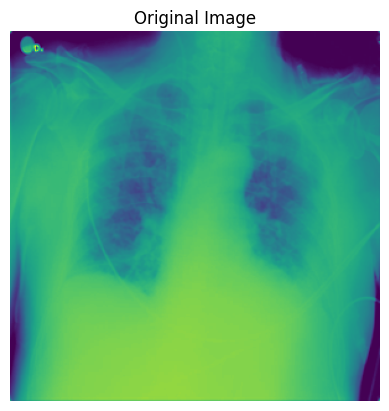

In [9]:
image_path = data[0]

# Load the image
img = Image.open(image_path)

# Display the image
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')  # Hide axes
plt.show()

## Gray Scale Conversion

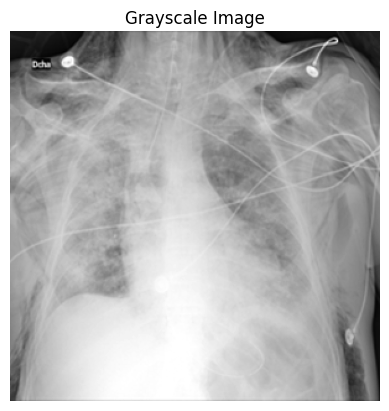

In [ ]:
# Convert the image to grayscale
img_gray = img.convert('L')  # 'L' mode is for grayscale

# Display the grayscale image
plt.imshow(img_gray, cmap='gray')  # squeeze to remove single-dimensional entries
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


## Converting Image to Numpy Array

In [ ]:
# Convert image to numpy array
img_array = img_to_array(img_gray)

# Print the shape of the array
print("Image shape:", img_array.shape)

Image shape: (299, 299, 1)


# Normalizing The Image

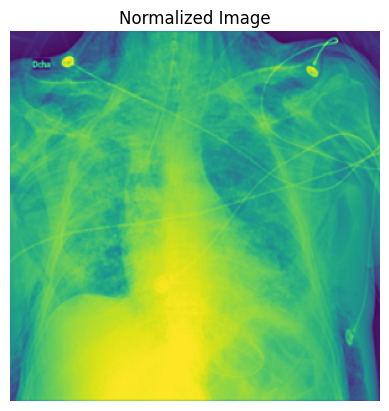

In [ ]:
# Normalize the image array
img_array_normalized = img_array.astype('float32') / 255.0

# Display the normalized image
plt.imshow(img_array_normalized)
plt.title("Normalized Image")
plt.axis('off')
plt.show()


## Resizing the Image

Although, All the Images in the dataset are of the size 299*299, so this step would apply while testing only.

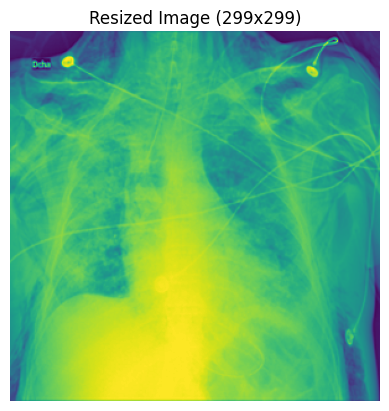

In [ ]:
# Resize the image
img_resized = img.resize((299, 299))

# Convert the resized image to a numpy array
img_resized_array = img_to_array(img_resized)

# Display the resized image
plt.imshow(img_resized_array.astype('uint8'))
plt.title("Resized Image (299x299)")
plt.axis('off')
plt.show()


## Hiatogram Equalization

/usr/local/lib/python3.10/dist-packages/skimage/_shared/utils.py:438: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


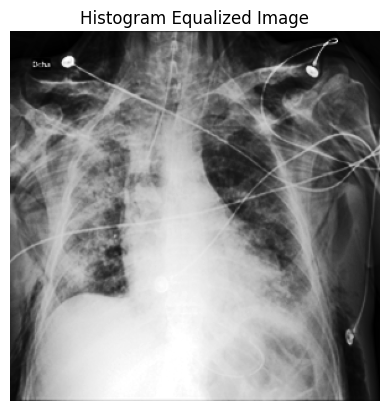

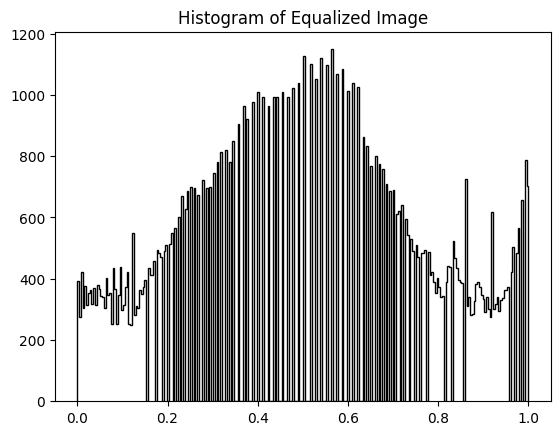

In [ ]:
# Apply histogram equalization
img_eq = exposure.equalize_hist(img_array_normalized)

# Display the equalized image
plt.imshow(img_eq, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()

# Plot the histogram
plt.hist(img_eq.ravel(), bins=256, histtype='step', color='black')
plt.title("Histogram of Equalized Image")
plt.show()


Let's Look at Different Phases of the Preprocessing.

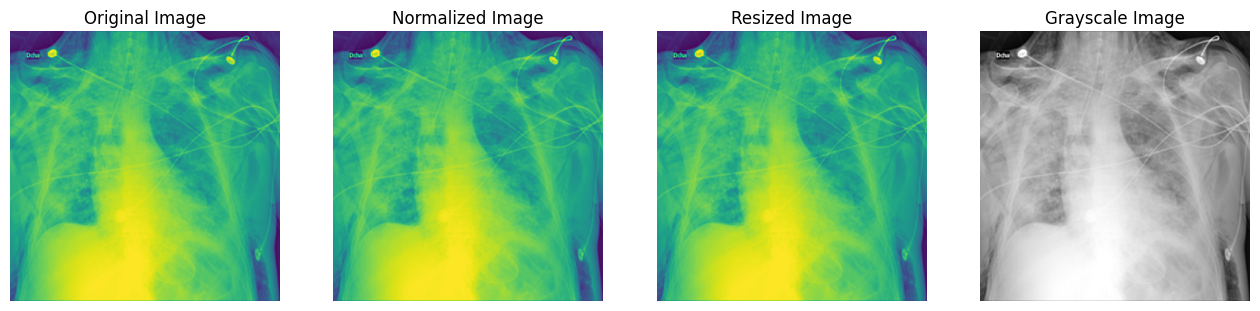

In [ ]:
# Plot original, normalized, resized, and grayscale images side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(img_array_normalized)
axes[1].set_title("Normalized Image")
axes[1].axis('off')

axes[2].imshow(img_resized_array.astype('uint8'))
axes[2].set_title("Resized Image")
axes[2].axis('off')

axes[3].imshow(img_gray, cmap='gray')
axes[3].set_title("Grayscale Image")
axes[3].axis('off')

plt.show()


# Applying Pre-Processing to the Whole Dataset

In [10]:
def preprocess(img_path):
  img = Image.open(image_path)
  img_gray = img.convert('L')  # 'L' mode is for grayscale
  img_array = img_to_array(img_gray)
  img_array_normalized = img_array.astype('float32') / 255.0
  img_eq = exposure.equalize_hist(img_array_normalized)
  return img_eq

In [11]:
preprocessed_images = []

In [12]:
for image_path in data:
  preprocessed_images.append(preprocess(image_path))

C:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\_shared\utils.py:438: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


In [13]:
preprocessed_images[0].shape

(299, 299, 1)

In [ ]:
preprocessed_images = np.array(preprocessed_images)
preprocessed_images.shape

# Visualizing the Dataset to Learn the trends

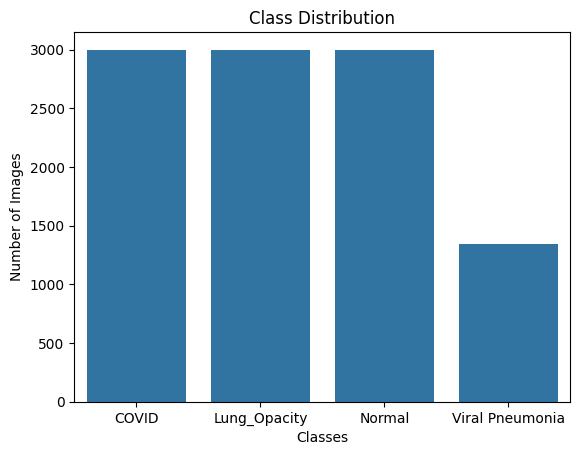

In [ ]:
categories = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

# Get unique labels and their counts
unique_labels, counts = np.unique(labels, return_counts=True)

# Create a dictionary for label counts
label_counts = dict(zip(unique_labels, counts))

# Plot the class distribution
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

The data in each class is almost equally Distributed which is quite obvious since we have read 3000 images from each section. This smooth distribution of data also makes it easy to classify without any biasness.

Plotting the **Pixel Intensity Distribution** Graph to learn the brightness and Contrast of Images.

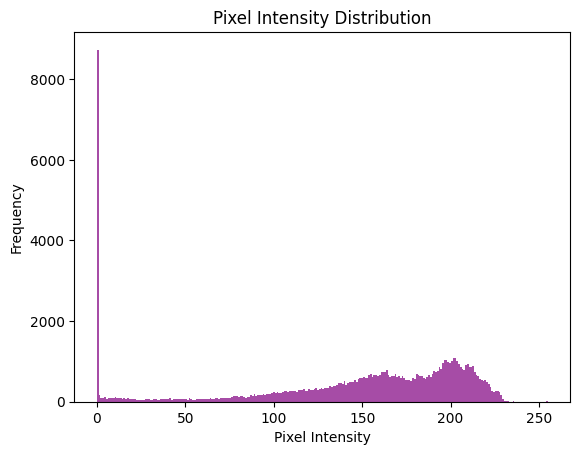

In [ ]:
# Flatten the pixel values to 1D array
img_path = data[1]
img = Image.open(image_path)
img_gray = img.convert('L')
img_gray_array = img_to_array(img_gray)
pixel_values = img_gray_array.flatten()

# Plot the histogram of pixel intensity values
plt.hist(pixel_values, bins=256, range=[0, 255], color='purple', alpha=0.7)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


A huge number of 0 shows that the images have a lot of black content. As we are examining the Images of an X-Rat, which consists of more black pixels.

#### Examinig the Nan Zero plot

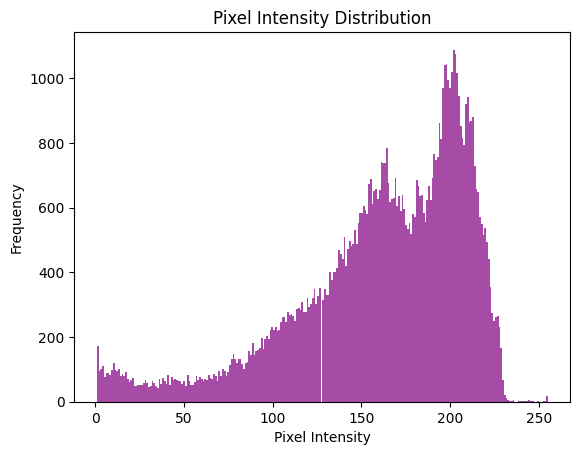

In [ ]:
# Flatten the pixel values to 1D array
img_path = data[1]
img = Image.open(image_path)
img_gray = img.convert('L')
img_gray_array = img_to_array(img_gray)
pixel_values = img_gray_array.flatten()

# Plot the histogram of pixel intensity values
plt.hist(pixel_values, bins=256, range=[1, 255], color='purple', alpha=0.7)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


A substantial number of pixels have higher intensity values, indicates that apart from having a lot of black pixels, there are bright areas in your images.

Plotting the **Mean and Standard Deviation of Images** Graph that also helps to learn the brightness and Contrast of Images.

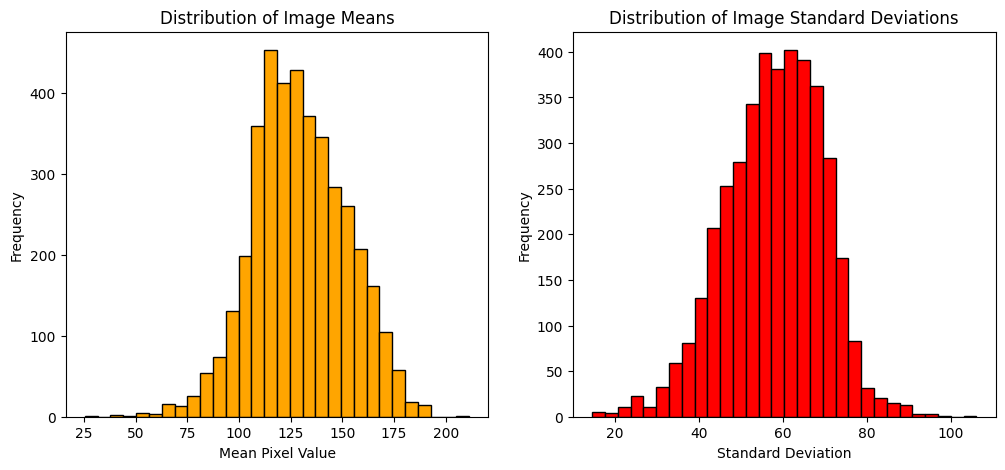

In [ ]:
means = []
stds = []

for category in categories:
    folder_path = f'/content/COVID-19_Radiography_Dataset/{category}/images'
    count = 0
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        if os.path.isfile(img_path):
            img = Image.open(img_path).convert('L')
            img_array = img_to_array(img).flatten()
            means.append(np.mean(img_array))
            stds.append(np.std(img_array))
        if count == 1000:
          break
        count += 1

# Plot the mean and standard deviation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(means, bins=30, color='orange', edgecolor='black')
plt.title("Distribution of Image Means")
plt.xlabel("Mean Pixel Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(stds, bins=30, color='red', edgecolor='black')
plt.title("Distribution of Image Standard Deviations")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")

plt.show()


A slightly left-skewed mean histogram indicates that most images in the dataset are relatively bright with few dark ones, while a slightly right-skewed standard deviation histogram shows that most images have low contrast but some exhibit high contrast variability.

Plotting some **Random Images** to learn the Trends

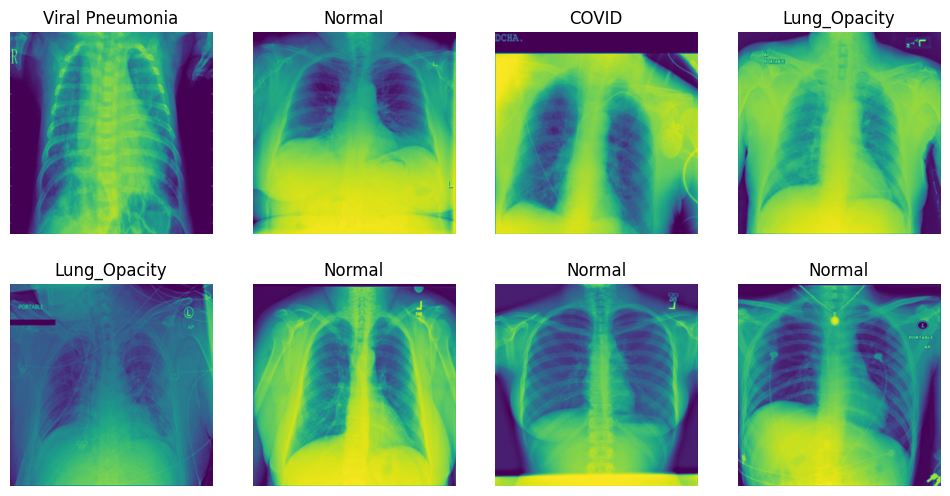

In [ ]:
import random

# Function to plot a grid of images
def plot_image_grid(categories, rows=2, cols=4):
    fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
    for i in range(rows):
        for j in range(cols):
            category = random.choice(categories)
            folder_path = f'/content/COVID-19_Radiography_Dataset/{category}/images'
            img_name = random.choice(os.listdir(folder_path))
            img_path = os.path.join(folder_path, img_name)
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(category)
            axes[i, j].axis('off')
    plt.show()

# Plot a grid of images
plot_image_grid(categories=categories)


# Building a Neural Network Model

In [ ]:
categories

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

In [ ]:
label_mapping = {
    "COVID": 0,
    "Lung_Opacity": 1,
    "Normal": 2,
    "Viral Pneumonia": 3
}

# Map the labels to integers
encoded_labels = np.array([label_mapping[label] for label in labels])

# Print the mapping and the encoded labels
print("Label mapping:", label_mapping)
print("Encoded labels:", encoded_labels)

Label mapping: {'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}
Encoded labels: [0 0 0 ... 3 3 3]


## Train Test Split

In [ ]:
preprocessed_images = np.array(preprocessed_images)
labels = np.array(encoded_labels)

# Split the data into training+validation and testing sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    preprocessed_images,
    labels,
    test_size=0.2,  # 20% for testing
    random_state=42
)

# Split the training+validation set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.2,  # 20% of the training+validation set for validation
    random_state=42
)


In [ ]:
# Print the shapes of the splits
print(f"Training images shape: {X_train.shape}")
print(f"Validation images shape: {X_val.shape}")
print(f"Testing images shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Validation labels shape: {y_val.shape}")
print(f"Testing labels shape: {y_test.shape}")

Training images shape: (2560, 299, 299, 1)
Validation images shape: (640, 299, 299, 1)
Testing images shape: (800, 299, 299, 1)
Training labels shape: (2560,)
Validation labels shape: (640,)
Testing labels shape: (800,)


## Structure of Neural Network

In [ ]:
model = Sequential()

# Convolutional Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(299, 299, 1)))
model.add(MaxPooling2D((2, 2)))

# Convolutional Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Convolutional Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))  # Adjust the number of units based on the number of classes

## Training The Network

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_val, y_val),
    batch_size=32
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 297, 297, 128)       │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 148, 148, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 148, 148, 128)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 146, 146, 64)        │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 161312)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │       2,581,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,674,612 (10.20 MB)

 Trainable params: 2,674,612 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 245ms/step - accuracy: 0.2424 - loss: 1.9891 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 183ms/step - accuracy: 0.2486 - loss: 1.4545 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.2506 - loss: 1.4855 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.2334 - loss: 1.4359 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.2427 - loss: 1.4665 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.2526 - loss: 1.4386 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.2310 - loss: 1.4086 - val_accuracy: 0.2625 - val_loss: 1.3863
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.2585 - loss: 1.5153 - val_accu

## Evaluating The Network

In [ ]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

ValueError: You must call `compile()` before using the model.

In [ ]:
# Save the entire model
model.save('/content/nn_model.h5')

# Visualizing The Loss and Accuracy

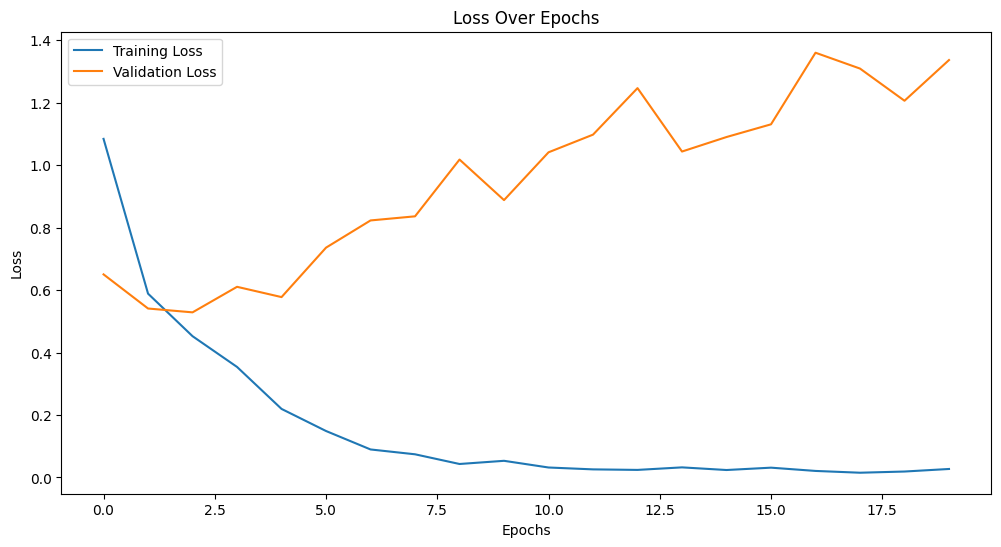

In [ ]:
# Plot loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



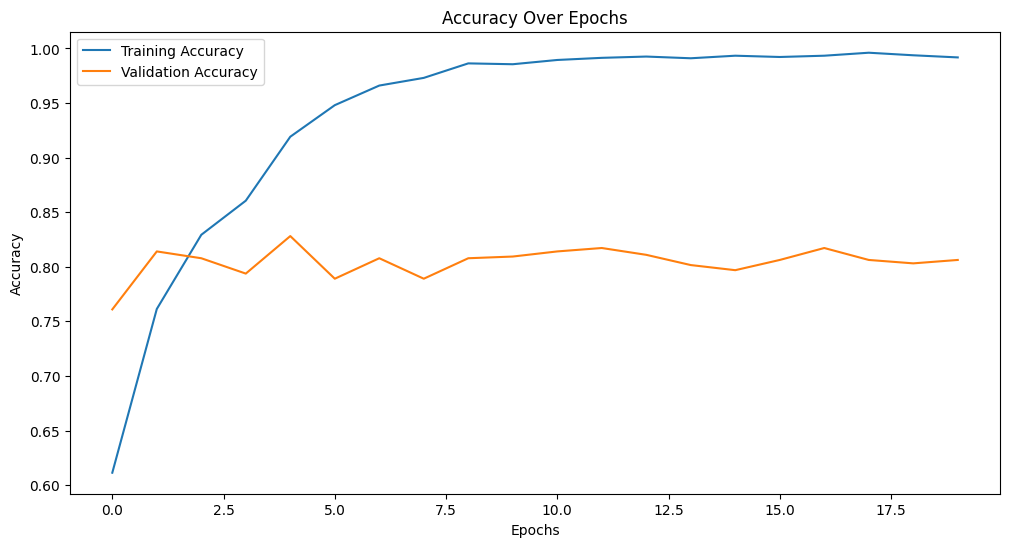

In [ ]:
# Plot accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()